## TCI - SVD truncation

We do SVD of central tensor to see how singular values decay. We expect that the lower singular values will be more affected by noise, and that the truncation will help to mitigate this effect.

We choose $\chi = iters = 7$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
#from scipy.sparse.linalg import eigsh, expm_multiply, expm

In [4]:
import importlib

import sys
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Correlation_function')
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Chebyshev")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/TCI")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Correlation_function")


import ED_Cs_Lsites as ED
import TCI_Lsite_accumulative_v1 as TCI

importlib.reload(ED)
importlib.reload(TCI)


<module 'TCI_Lsite_accumulative_v1' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI/TCI_Lsite_accumulative_v1.py'>

In [5]:
# define Hamiltonian terms
L = 11
n = 11
dt = 1e-2
models = ['J = 1, g = 2 , Ising Model Ham. = H','J =1 g = 2 Ham. = H - k*Hzz', 'J = 1 g = 0.5, Ham. = H - h * Hxx', 'J = 1 g = 0.5, Ham. = H - k*Hzz - h*Hxx']
threshold = 30
N = 2**n
D = L
g_par = 0.1


In [6]:
# Generate Hamiltonian
Hlist = [ED.gen_Ham(L = L, model = 0), ED.gen_Ham(L = L, model = 2)]

In [7]:
Cs_theo = ED.correlator(H= Hlist[0], L = L, dt = dt,  n = n)
print(Cs_theo.shape)

for i in range(Cs_theo.shape[0]):
    for k in range(Cs_theo.shape[1]):
        if Cs_theo.real[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = 1. + 1j* Cs_theo.imag[i,k]
        if Cs_theo.imag[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = Cs_theo.real[i,k] + 1j

Expectation value $\bra{\psi_0} X_{L/2} \ket{psi_0}$=  1.9365925444093488e-16
(11, 2048)
i,k: ( 5 , 0 ),  (1.0000000000000038+0j)


In [8]:
N_shots = 2**13 #8192 rough estimation by Bernhard
# clip to avoid tiny negative values from rounding
std_real = np.sqrt(np.clip(1 - Cs_theo.real**2, 0, None)) / np.sqrt(N_shots)
std_imag = np.sqrt(np.clip(1 - Cs_theo.imag**2, 0, None)) / np.sqrt(N_shots)

np.random.seed(0)  # optional
Cs_noise_real = np.random.normal(loc=0.0, scale=std_real)
Cs_noise_imag = np.random.normal(loc=0.0, scale=std_imag)

Cs_noise = Cs_theo + Cs_noise_real + 1j * Cs_noise_imag
print("shapes:", Cs_theo.shape, Cs_noise.shape)

shapes: (11, 2048) (11, 2048)


In [9]:
diff_noisevstheo = Cs_theo-Cs_noise #should be difference between 2 matrices
err_max_noisevstheo = np.max(np.abs(diff_noisevstheo))/np.max(np.abs(Cs_theo))
print("Max error (noise vs theo): ", err_max_noisevstheo)
err_2_noisevstheo = np.linalg.norm(diff_noisevstheo)/np.linalg.norm(Cs_theo)
print("2-norm error (noise vs theo): ", err_2_noisevstheo)

Max error (noise vs theo):  0.051442664338269994
2-norm error (noise vs theo):  0.04675541920299879


In [10]:
# D = L #already defined above

func_vals_theo = Cs_theo.T #Cs is in the form (X,T)
func_vals_noise = Cs_noise.T

#first we define the function f(t)
# which returns the slice of func_vals along x for a specific time 
f_t_theo = lambda *t: Cs_theo.reshape((D,) + (2,) * n)[:,*t]
f_t_noise = lambda *t: Cs_noise.reshape((D,) + (2,) * n)[:,*t]

In [11]:
func_noise = TCI.function(f_t_noise)
chi = 8

As, _, eval, err_2, err_max, func_interp_noise = TCI.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.06383942847687811
err_2:  0.06476828036872226

repeated evaluations:  8876
unique evaluations 640
unique + repeated:  9516
total evaluations:  9516



In [ ]:
n_half = n//2

# We can look at the singular values of the central tensor to see how they decay, and how the noise affects them. We expect that the lower singular values will be more affected by noise, and that the truncation will help to mitigate this effect.

As_central = As[n_half]
print(As_central.shape)
As_central = np.reshape(As_central, (chi, chi*2))
U, S, Vh = np.linalg.svd(As_central, full_matrices=False)


(8, 2, 8)


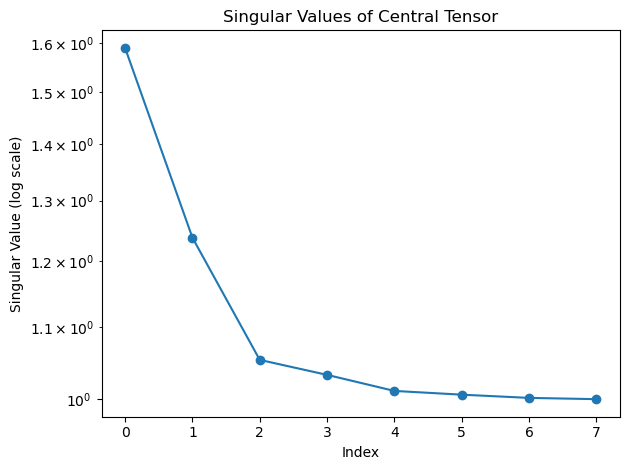

In [ ]:
plt.semilogy(S, 'o-')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of Central Tensor')
plt.tight_layout()
# plt.savefig("figures_Lsite_noise/singular_values_central_tensor_D11_n11.pdf")
plt.show()

In [ ]:
def interpolate_func(As):
    func_interp = np.squeeze(As[-1]) #now has two legs: ab

    for A in As[-2:0:-1]:
        func_interp = np.einsum('idk, kj -> idj', A, func_interp)
        func_interp = func_interp.reshape(A.shape[0], -1)
    if As[0].shape[0] == D:
        #print(As[0].shape)
        func_interp = np.einsum('dak, kj -> daj', np.squeeze(As[0]), func_interp)
        #func_interp = np.einsum('ak, kj -> aj', np.squeeze(As[0]), func_interp) #uncomment this in case D = 1
        func_interp = np.transpose(func_interp, [1,2,0])
        #print("func interp shape = ", func_interp.shape)
        
        func_interp = func_interp.reshape(-1, D)
        #func_interp = func_interp.reshape(-1) #uncomment this in case D = 1
        return func_interp
    else: 
        return print("Error")

In [ ]:
# ...existing code...
chi_list = [8,7,6,5,4,3]
err_max_list = []
err_2_list = []

# capture full interpolation before truncation
func_interp = interpolate_func(As)
difference = func_vals_theo - func_interp
err_max_list.append(np.max(np.abs(difference)) / np.max(np.abs(func_vals_theo)))
err_2_list.append(np.linalg.norm(difference) / np.linalg.norm(func_vals_theo))

# reshape central tensor (keep a copy)
As_central = As[n_half]
orig_shape = As_central.shape
Ac_mat = np.reshape(As_central, (orig_shape[0], orig_shape[1] * orig_shape[2]))

# compute SVD once (or you can recompute inside loop if preferred)
U, S, Vh = np.linalg.svd(Ac_mat, full_matrices=False)

for el in chi_list[1:]:
    # build truncated central matrix
    U_tr = U[:, :el]
    S_tr = S[:el]
    Vh_tr = Vh[:el, :]

    Ac_tr = U_tr @ np.diag(S_tr) @ Vh_tr
    Ac_tr_shaped = Ac_tr.reshape(orig_shape)

    # copy As and replace central tensor
    As_tr = [a.copy() for a in As]
    As_tr[n_half] = Ac_tr_shaped

    # interpolate and compute errors
    func_interp = interpolate_func(As_tr)
    difference = func_vals_theo - func_interp
    err_max_list.append(np.max(np.abs(difference)) / np.max(np.abs(func_vals_theo)))
    err_2_list.append(np.linalg.norm(difference) / np.linalg.norm(func_vals_theo))
# ...existing code...

In [ ]:
print(err_max_list)
print(err_2_list)

[np.float64(0.03892987194860091), np.float64(0.18089444824160206), np.float64(0.18514436344981683), np.float64(0.31203077799901635), np.float64(0.43987096571442913), np.float64(0.6592234597241898)]
[np.float64(0.046114449417403225), np.float64(0.0693353634508758), np.float64(0.07107637657658919), np.float64(0.10112251584615466), np.float64(0.1269705606789235), np.float64(0.23304051787955096)]


Text(0.5, 1.0, 'Errors vs $\\chi$')

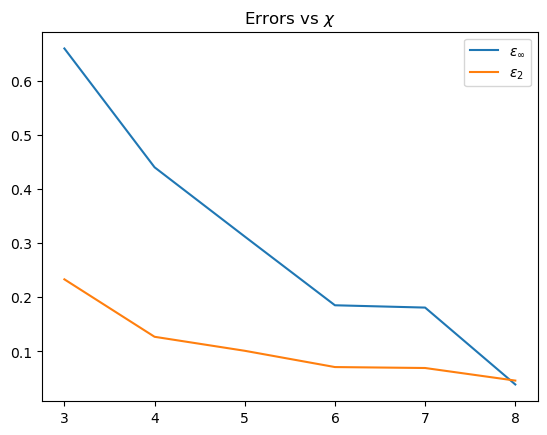

In [ ]:
# x = np.arange(len(err_max_list))
plt.plot(chi_list, err_max_list, label = r'$\epsilon_\infty$')
plt.plot(chi_list, err_2_list, label=r'$\epsilon_2$')
plt.legend()
plt.title(r'Errors vs $\chi$')

## same procedure for other tensors

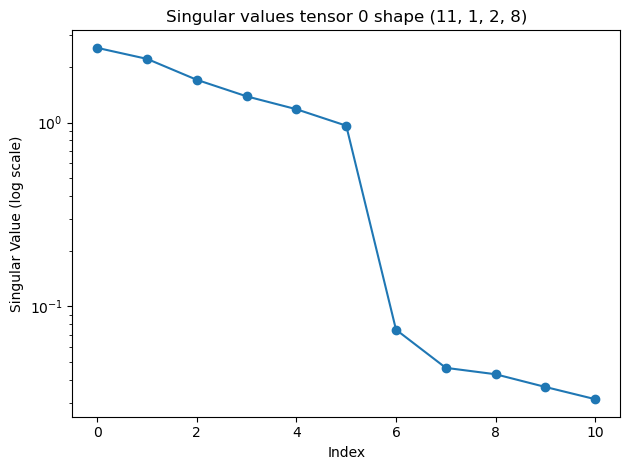

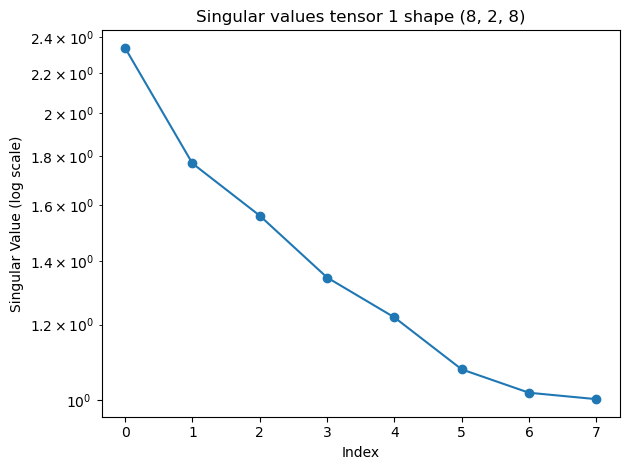

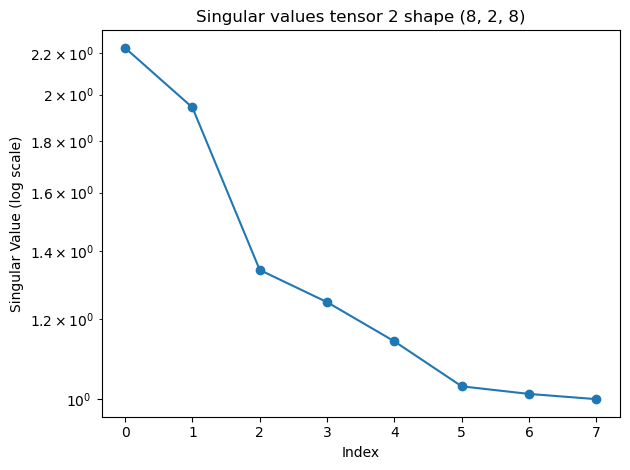

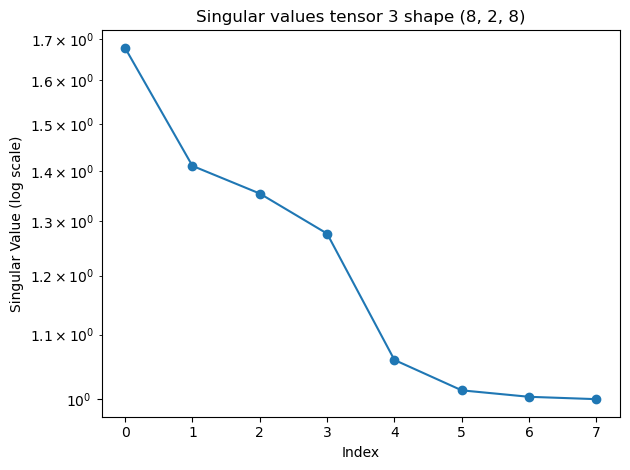

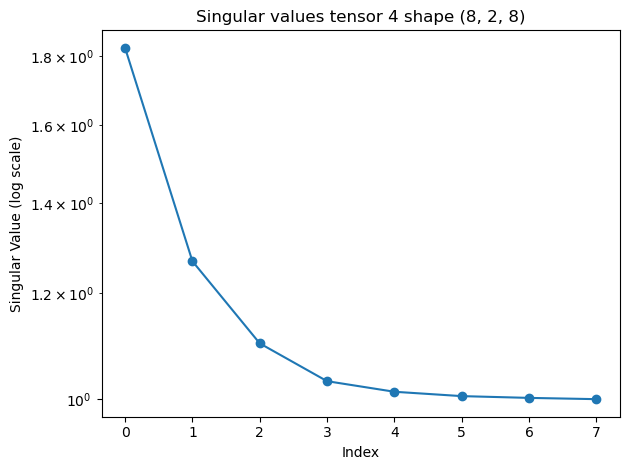

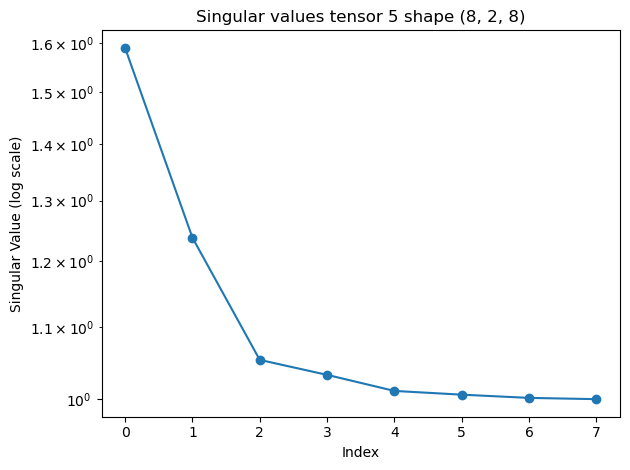

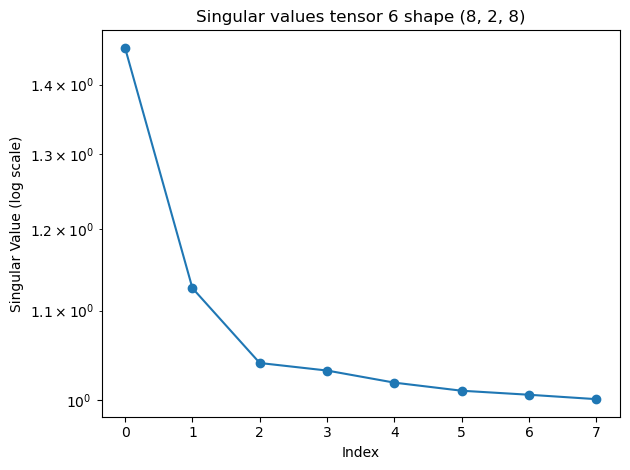

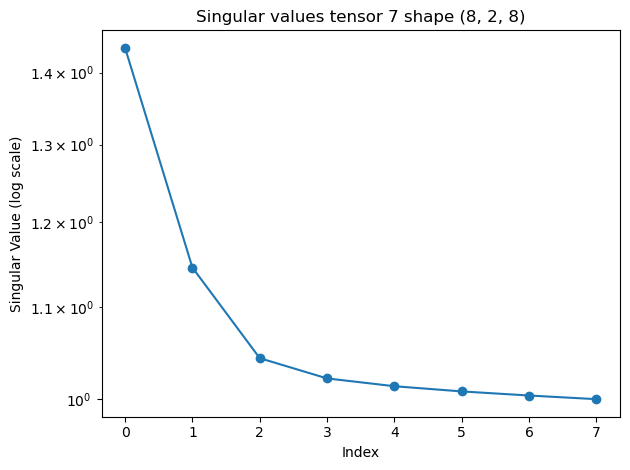

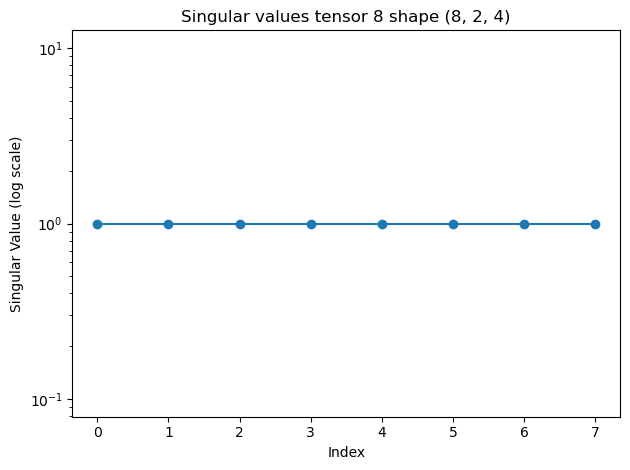

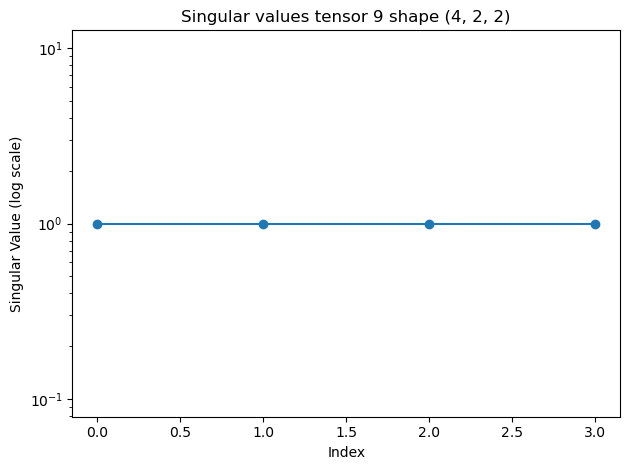

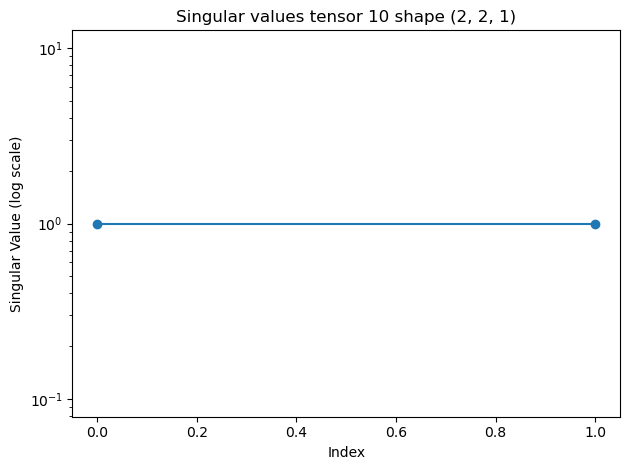

In [ ]:
# ...existing code...
def tensor_to_matrix(A):
    A_orig_shape = A.shape
    A_s = np.squeeze(A)
    s = A_s.shape
    if A_s.ndim == 1:
        mat = A_s.reshape(-1, 1)
    elif A_s.ndim == 2:
        mat = A_s
    elif A_s.ndim == 3:
        mat = A_s.reshape(s[0], s[1] * s[2])
    elif A_s.ndim == 4:
        mat = A_s.reshape(s[0] * s[1], s[2] * s[3])
    else:
        raise ValueError(f"Unsupported tensor ndim={A_s.ndim}, shape={A_orig_shape}")
    return mat, A_s.shape, A_orig_shape

def matrix_to_tensor(mat, squeezed_shape, orig_shape):
    # ricostruisce prima nella shape squeezed, poi riconduce a shape originale
    A_s = mat.reshape(squeezed_shape)
    return A_s.reshape(orig_shape)

# esempio: calcola SVD per ogni tensore in As e plotta le singolari
for idx, A in enumerate(As):
    mat, squeezed_shape, orig_shape = tensor_to_matrix(A)
    # optional: skip troppo piccoli
    if min(mat.shape) < 1:
        print(f"skip tensor {idx} shape {orig_shape}")
        continue
    U, S, Vh = np.linalg.svd(mat, full_matrices=False)
    plt.plot(S, 'o-')
    plt.yscale('log')
    plt.xlabel('Index')
    plt.ylabel('Singular Value (log scale)')
    plt.title(f'Singular values tensor {idx} shape {orig_shape}')
    plt.tight_layout()
    plt.show()

In [ ]:
def error_after_truncation(As_tr):
    func_interp = interpolate_func(As_tr)
    difference = func_vals_theo - func_interp
    err_max = np.max(np.abs(difference)) / np.max(np.abs(func_vals_theo))
    err_2 = np.linalg.norm(difference) / np.linalg.norm(func_vals_theo)
    return err_max, err_2

def error_vs_chi(As, sing_values_dict):
    """
    I expect chi_dict ={'n': [list of chi values to test]}
    """
    err_max_dict = {}
    err_2_dict = {}
    
    # compute full interpolation error
    err_max_full, err_2_full = error_after_truncation(As)

    for n in sing_values_dict.keys():
        err_max_dict[n] = [err_max_full]  # start with full chi error
        err_2_dict[n] = [err_2_full]
        A_n = As[n]
        mat_n, sq_shape, orig_shape = tensor_to_matrix(A_n)
        U, S, Vh = np.linalg.svd(mat_n, full_matrices=False)
        for el in sing_values_dict[n][1:]:  # skip full chi since it's already computed
            mat_tr = U[:, :el] @ np.diag(S[:el]) @ Vh[:el, :]
            A_n_tr = matrix_to_tensor(mat_tr, sq_shape, orig_shape)
            As_tr = [a.copy() for a in As]
            As_tr[n] = A_n_tr
            err_max, err_2 = error_after_truncation(As_tr)
            err_max_dict[n].append(err_max)
            err_2_dict[n].append(err_2)
    return err_max_dict, err_2_dict


In [ ]:
# sing_values_dict = {n: chi_list for n in range(0, len(As)-1)}  # assuming we want to test all tensors except the last one
sing_values_dict = {0: [11,10,9,8,7,6]}
err_max_dict, err_2_dict = error_vs_chi(As, sing_values_dict)

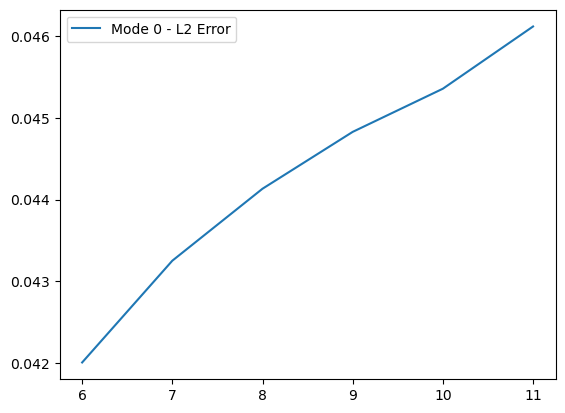

In [ ]:
for n in err_max_dict.keys():
    # plt.plot(chi_dict[n], err_max_dict[n], label=f"Mode {n} - Max Error")
    plt.plot(sing_values_dict[n], err_2_dict[n], label=f"Mode {n} - L2 Error")
    plt.legend()

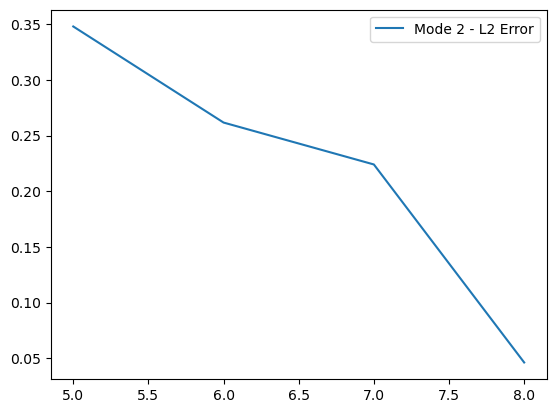

In [ ]:
# sing_values_dict = {n: chi_list for n in range(0, len(As)-1)}  # assuming we want to test all tensors except the last one
sing_values_dict = {2: [8,7,6,5]}
err_max_dict, err_2_dict = error_vs_chi(As, sing_values_dict)
for n in err_max_dict.keys():
    # plt.plot(chi_dict[n], err_max_dict[n], label=f"Mode {n} - Max Error")
    plt.plot(sing_values_dict[n], err_2_dict[n], label=f"Mode {n} - L2 Error")
    plt.legend()

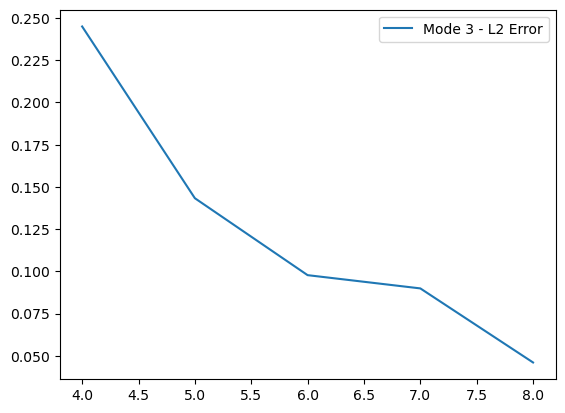

In [ ]:
# sing_values_dict = {n: chi_list for n in range(0, len(As)-1)}  # assuming we want to test all tensors except the last one
sing_values_dict = {3: [8,7,6,5,4]}
err_max_dict, err_2_dict = error_vs_chi(As, sing_values_dict)
for n in err_max_dict.keys():
    # plt.plot(chi_dict[n], err_max_dict[n], label=f"Mode {n} - Max Error")
    plt.plot(sing_values_dict[n], err_2_dict[n], label=f"Mode {n} - L2 Error")
    plt.legend()